In [5]:
import sys
from dotenv import load_dotenv

load_dotenv(r"c:\Users\admin\demand-forecasting\.env")

sys.path.append(r"c:\Users\admin\demand-forecasting")

In [9]:
import pandas as pd
import numpy as np
from etl.load import get_engine
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm


In [13]:
engine = get_engine()

In [ ]:
query1 = '''
        SELECT quantite, COUNT(*) as freq
        FROM fact_sales
        GROUP BY quantite
        ORDER BY quantite
    '''

df_sales = pd.read_sql(query1, engine)

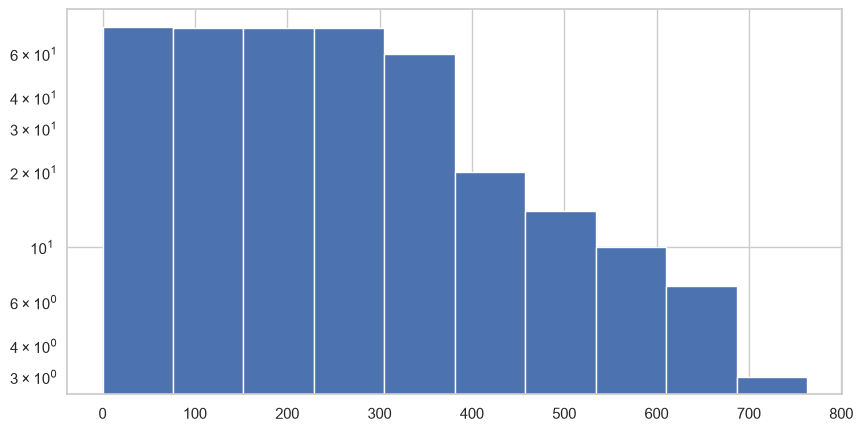

In [10]:
plt.figure(figsize=(10,5))
df_sales["quantite"].hist()
plt.yscale("log")
plt.show()

In [59]:
query2 = '''
    SELECT item_id, 
           COUNT(*) AS total_jours,
           COUNT(*) FILTER (WHERE quantite=0) AS jour_zero_sales,
           (COUNT(*) FILTER (WHERE quantite=0) * 100.0) / COUNT(*) AS pct_jours
    FROM fact_sales
    GROUP BY item_id
'''

df_pct_jour_item = pd.read_sql(query2, engine)
df_pct_jour_item.head()

,item_id,total_jours,jour_zero_sales,pct_jours
0,1,19130,16190,84.631469
1,2,19130,15160,79.247256
2,3,19130,17954,93.852588
3,4,19130,7299,38.154731
4,5,19130,11383,59.503398


In [60]:
query3 = '''
    SELECT store_id, 
           COUNT(*) AS total_jours,
           COUNT(*) FILTER (WHERE quantite=0) AS jour_zero_sales,
           (COUNT(*) FILTER (WHERE quantite=0) * 100.0) / COUNT(*) AS pct_jours
    FROM fact_sales
    GROUP BY store_id
'''

df_pct_jour_store = pd.read_sql(query3, engine)
df_pct_jour_store.head()

,store_id,total_jours,jour_zero_sales,pct_jours
0,1,5832737,3729880,63.947337
1,2,5832737,4030918,69.108516
2,3,5832737,3476386,59.601282
3,4,5832737,4209754,72.174590
4,5,5832737,4132649,70.852655


In [61]:
query_pct_global = '''
    SELECT 
        (COUNT(*) FILTER (WHERE quantite = 0) * 100.0) / COUNT(*) AS pct_zero_global
    FROM fact_sales
'''

df_pct_global = pd.read_sql(query_pct_global, engine)
print(df_pct_global)

   pct_zero_global
0        68.196276


we can see that about of 60% of store and 70% of items haves 0 sales per day

In [ ]:
query4 = """
    select i.categorie, sum(f.quantite) as nbr_sales
    from item i join fact_sales f on i.id = f.item_id
    group by i.categorie
"""

quantite_par_categorie = pd.read_sql(query4, engine)

quantite_par_categorie.head()

,categorie,nbr_sales
0,FOODS,45089939
1,HOBBIES,6124800
2,HOUSEHOLD,14480670


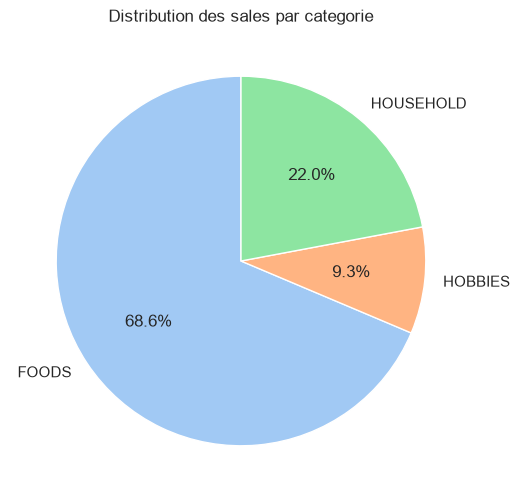

In [ ]:
# Application du style Seaborn
sns.set_theme(style="whitegrid")

# Récupération d'une palette de couleurs Seaborn (ex: 'pastel', 'Set2', 'viridis')
couleurs = sns.color_palette('pastel')[0:len(quantite_par_categorie["nbr_sales"])]

plt.figure(figsize=(6, 6))
plt.pie(
    quantite_par_categorie["nbr_sales"], 
    labels=quantite_par_categorie["categorie"], 
    autopct='%1.1f%%', 
    colors=couleurs,
    startangle=90
)

plt.title('Distribution des sales par categorie')
plt.show()

we can observe that clearly foods domainant the sales by 68.6% then comes household with 22% then the rest is for hobbiesw with 9.3%

In [ ]:
query5 = """
    select s.etat, sum(f.quantite) as nbr_sales
    from store s join fact_sales f on s.id = f.store_id
    group by s.etat
"""

quantite_par_etat = pd.read_sql(query5, engine)

quantite_par_etat.head()

,etat,nbr_sales
0,CA,28675547
1,TX,18899006
2,WI,18120856


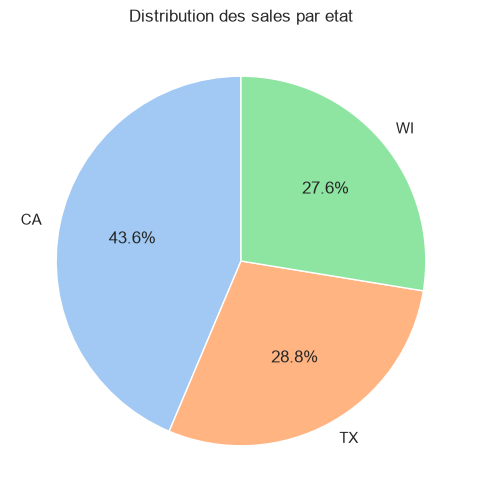

In [ ]:
# Application du style Seaborn
sns.set_theme(style="whitegrid")

# Récupération d'une palette de couleurs Seaborn (ex: 'pastel', 'Set2', 'viridis')
couleurs = sns.color_palette('pastel')[0:len(quantite_par_etat["nbr_sales"])]

plt.figure(figsize=(6, 6))
plt.pie(
    quantite_par_etat["nbr_sales"], 
    labels=quantite_par_etat["etat"], 
    autopct='%1.1f%%', 
    colors=couleurs,
    startangle=90
)

plt.title('Distribution des sales par etat')
plt.show()

it's really clear that CA state comes first with 43.6% of sales then comnes TX and WI with 28% each

**Temporel**

In [22]:
query6= '''
            select d.la_date, sum(quantite) as quantite_vendues
            from dim_date d join fact_sales f on d.id = f.date_id
            group by d.id
        '''

quantite_per_day = pd.read_sql(query6, engine)

quantite_per_day.head()

,la_date,quantite_vendues
0,2011-01-29,32631
1,2011-01-30,31749
2,2011-01-31,23783
3,2011-02-01,25412
4,2011-02-02,19146


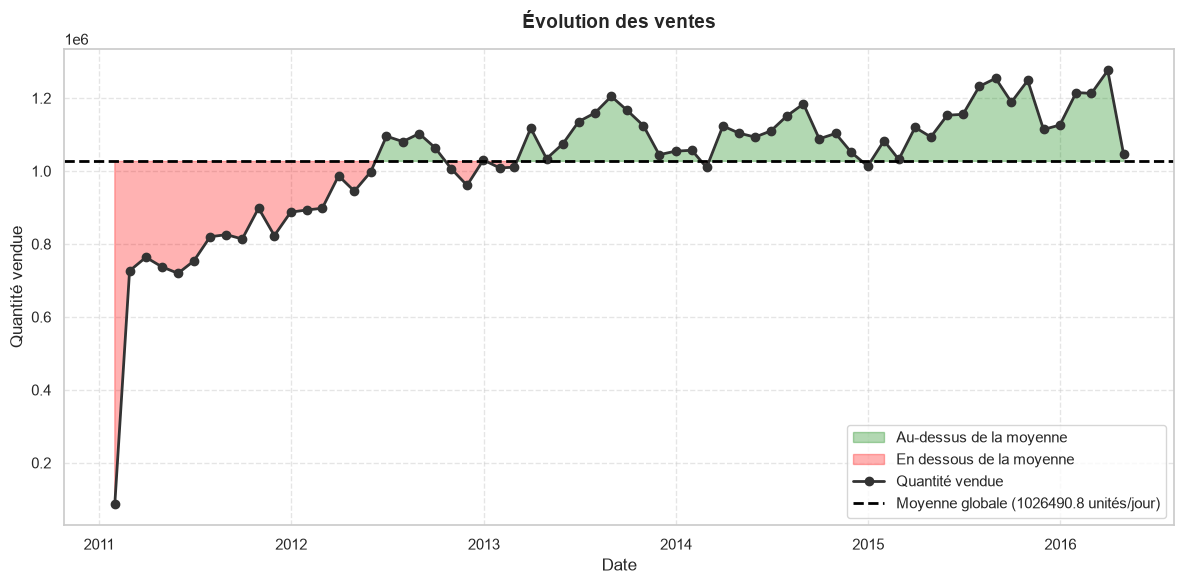

In [28]:
quantite_per_day["la_date"] = pd.to_datetime(
    quantite_per_day["la_date"]
)

# Calcul des ventes totales mensuelles
df_monthly = (
    quantite_per_day
    .set_index("la_date")
    .resample("ME")["quantite_vendues"]
    .sum()
)

# Calcul de la moyenne globale sur toute la période
mean_overall = df_monthly.mean()

# Configuration de la figure
plt.figure(figsize=(12, 6))

# Remplir en vert la zone où la courbe est au-dessus de la moyenne
plt.fill_between(
    df_monthly.index,
    df_monthly.values,
    mean_overall,
    where=(df_monthly.values >= mean_overall),
    interpolate=True,
    color="green",
    alpha=0.3,
    label="Au-dessus de la moyenne"
)

# Remplir en rouge la zone où la courbe est en dessous de la moyenne
plt.fill_between(
    df_monthly.index,
    df_monthly.values,
    mean_overall,
    where=(df_monthly.values < mean_overall),
    interpolate=True,
    color="red",
    alpha=0.3,
    label="En dessous de la moyenne"
)

# Tracé de la courbe d'évolution mensuelle
plt.plot(
    df_monthly.index,
    df_monthly.values,
    marker="o",
    linestyle="-",
    color="#333333",
    linewidth=2,
    label="Quantité vendue"
)

# Tracé de la ligne de moyenne globale
plt.axhline(
    y=mean_overall,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Moyenne globale ({mean_overall:.1f} unités/jour)"
)

# Habillage et clarté du graphique
plt.title(
    "Évolution des ventes",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Quantité vendue", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="best", fontsize=11)

plt.tight_layout()
plt.show()

### Interprétation

* Les ventes montrent une **tendance globalement croissante** entre 2011 et 2013, passant d’environ **0,7–0,8 million** à plus de **1 million d’unités par mois**.
* À partir de 2013, les ventes se **maintiennent à un niveau élevé**, généralement autour de **1,0 à 1,2 million d’unités par mois**.
* La moyenne mensuelle est d’environ **1,03 million d’unités** ; la majorité des mois après 2013 sont **au-dessus de cette moyenne**.
* Malgré cette tendance positive, on observe des **fluctuations mensuelles importantes**, ce qui peut indiquer une **saisonnalité ou des effets calendaires**.
* Les niveaux les plus élevés apparaissent vers **2015–2016**, avec des pics dépassant **1,2 million d’unités**.


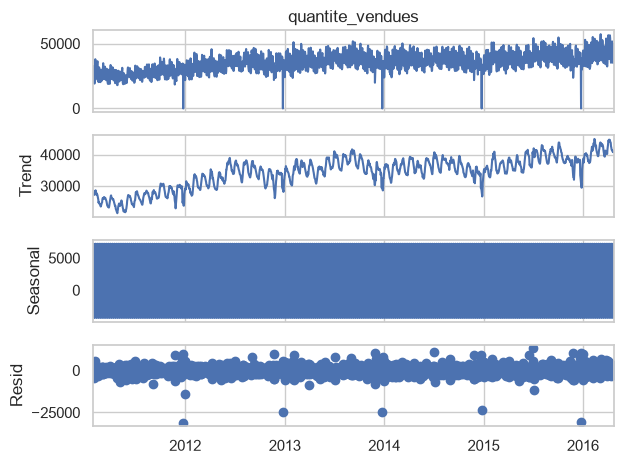

In [ ]:
daily_sales = (
    quantite_per_day
    .set_index("la_date")["quantite_vendues"]
    .resample("D")
    .sum()
)

decomp_weekly = seasonal_decompose(
    daily_sales,
    model="additive",
    period=7
)

plt.Figure(figsize=(10,6))
decomp_weekly.plot()
plt.tight_layout()
plt.show()

La décomposition met en évidence une tendance globale à la hausse des ventes, accompagnée d’une saisonnalité hebdomadaire. Les résidus sont généralement faibles mais présentent quelques anomalies ponctuelles, indiquant l’existence d’événements exceptionnels ou de variations non expliquées par la tendance et la saisonnalité(il peut etre des weekends ou des jours firiés).

<Figure size 1200x800 with 0 Axes>

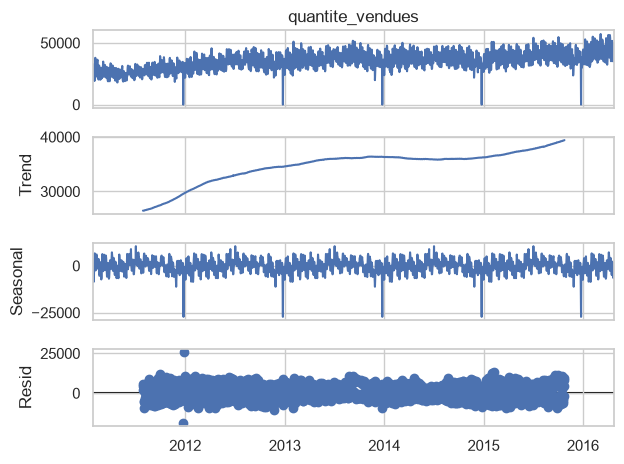

In [57]:
decomp_yearly = seasonal_decompose(
    daily_sales,
    model="additive",
    period=365
)

plt.figure(figsize=(12, 8))
decomp_yearly.plot()
plt.tight_layout()
plt.show()

La décomposition annuelle met en évidence une tendance croissante des ventes et suggère la présence d’un cycle saisonnier annuel, avec quelques fluctuations exceptionnelles visibles dans les résidus.

In [41]:
query7= '''
            select d.la_date, jour_de_semaine, is_weekend, is_holiday, sum(quantite) as quantite_vendues
            from dim_date d join fact_sales f on d.id = f.date_id
            group by d.id
        '''

quantite_per_day_holiday = pd.read_sql(query7, engine)

quantite_per_day_holiday.head()

,la_date,jour_de_semaine,is_weekend,is_holiday,quantite_vendues
0,2011-01-29,Saturday,True,False,32631
1,2011-01-30,Sunday,True,False,31749
2,2011-01-31,Monday,False,False,23783
3,2011-02-01,Tuesday,False,False,25412
4,2011-02-02,Wednesday,False,False,19146


In [42]:
quantite_per_day_holiday.groupby('is_weekend')['quantite_vendues'].agg(
    ['mean','median','sum','count']
)

,mean,median,sum,count
is_weekend,,,,
False,31532.552381,31995.0,43041934,1365
True,41338.458029,42526.5,22653475,548


In [43]:
quantite_per_day_holiday.groupby('is_holiday')['quantite_vendues'].agg(
    ['mean','median','sum','count']
)

,mean,median,sum,count
is_holiday,,,,
False,34489.207504,33714.0,60666516,1759
True,32655.149351,33779.5,5028893,154


Le week-end présente un effet positif marqué sur les volumes, avec des ventes moyennes supérieures d’environ 31 % aux jours ouvrés.

 À l’inverse, les jours fériés sont associés à une légère baisse des ventes, d’environ 5 %.
 
  L’effet du week-end semble donc beaucoup plus important que celui des jours fériés.

In [44]:
quantite_per_day_holiday.groupby("jour_de_semaine")["quantite_vendues"].agg(["mean", "median", "count"])

,mean,median,count
jour_de_semaine,,,
Friday,34225.985348,34775.0,273
Monday,32852.967033,33444.0,273
Saturday,41546.894161,42437.0,274
Sunday,41130.021898,42586.0,274
Thursday,30205.007326,30658.0,273
Tuesday,30368.780220,30710.0,273
Wednesday,30010.021978,30911.0,273


Les ventes présentent un effet très marqué du jour de la semaine :

Samedi et dimanche enregistrent les volumes les plus élevés, autour de 41 000 unités.

Vendredi et lundi présentent des niveaux intermédiaires.

Mercredi est le jour où les ventes sont les plus faibles, autour de 30 000 unités.

La demande augmente donc nettement en fin de semaine et pendant le week-end, tandis qu’elle est plus faible en milieu de semaine.

**stasionarité**

H₀ : la série n'est pas stationnaire

H₁ : la série est stationnaire

In [49]:
result = adfuller(daily_sales.dropna())

print("ADF statistic :", result[0])
print("p-value :", result[1])

ADF statistic : -1.565373325331847
p-value : 0.5009604361797743


La série globale peut être considérée comme non stationnaire.

In [50]:
daily_sales_diff = daily_sales.diff().dropna()

result = adfuller(daily_sales_diff)

print("ADF statistic :", result[0])
print("p-value :", result[1])

ADF statistic : -23.45957882063267
p-value : 0.0


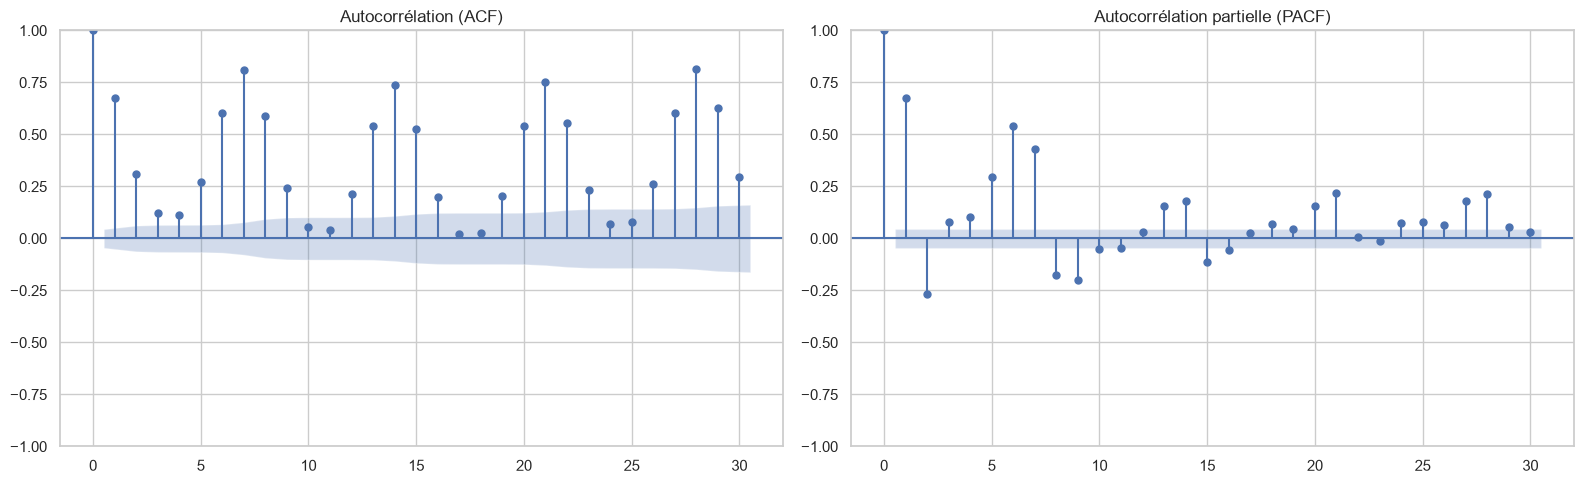

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(daily_sales, lags=30, ax=axes[0])
axes[0].set_title("Autocorrélation (ACF)")

plot_pacf(daily_sales, lags=30, ax=axes[1])
axes[1].set_title("Autocorrélation partielle (PACF)")

plt.tight_layout()
plt.show()

ACF : pics nets et récurrents aux lags 7, 14, 21, 28 — confirmation claire de la saisonnalité hebdomadaire déjà détectée par seasonal_decompose. Le lag 1 est aussi élevé (~0.67), indiquant une forte corrélation d'un jour sur l'autre. La décroissance lente entre les pics (au lieu d'une chute brutale) est typique d'une série non-stationnaire — cohérent avec ton test ADF initial.

PACF : coupure nette après le lag 1-2 — seuls les lags 1 (positif, ~0.67) et 2 (négatif, ~-0.27) sortent clairement de la zone de confiance, avec un pic supplémentaire au lag 6-7 (l'effet saisonnier hebdomadaire résiduel une fois l'autocorrélation directe retirée). Au-delà, presque tout reste dans la zone bleue.

Implication concrète : si tu utilises un modèle ARIMA plus tard, cette PACF suggère un ordre autorégressif faible (AR(1) ou AR(2)), combiné à un terme saisonnier explicite à la période 7 — pas besoin d'un modèle avec des dizaines de lags.

In [64]:
query_intermittency = '''
    SELECT 
        item_id,
        store_id,
        COUNT(*) AS total_jours,
        COUNT(*) FILTER (WHERE quantite = 0) AS jours_zero,
        (COUNT(*) FILTER (WHERE quantite = 0) * 100.0) / COUNT(*) AS pct_zero,
        AVG(quantite) FILTER (WHERE quantite > 0) AS moyenne_non_zero,
        STDDEV(quantite) FILTER (WHERE quantite > 0) AS ecart_type_non_zero
    FROM fact_sales
    GROUP BY item_id, store_id
'''

df_intermittency = pd.read_sql(query_intermittency, engine)

# Coefficient de variation au carré (CV²) sur les ventes non-nulles
df_intermittency['cv2'] = (df_intermittency['ecart_type_non_zero'] / df_intermittency['moyenne_non_zero']) ** 2

# Intervalle moyen entre deux ventes non-nulles (ADI)
df_intermittency['adi'] = df_intermittency['total_jours'] / (df_intermittency['total_jours'] - df_intermittency['jours_zero'])

def classify_demand(row):
    if row['adi'] < 1.32 and row['cv2'] < 0.49:
        return 'lisse'
    elif row['adi'] >= 1.32 and row['cv2'] < 0.49:
        return 'intermittent'
    elif row['adi'] < 1.32 and row['cv2'] >= 0.49:
        return 'erratique'
    else:
        return 'grumeleux'

df_intermittency['categorie_demande'] = df_intermittency.apply(classify_demand, axis=1)

print(df_intermittency['categorie_demande'].value_counts())

categorie_demande
intermittent    23054
grumeleux        5959
lisse             979
erratique         498
Name: count, dtype: int64


95.1% des séries (intermittent + grumeleux) ont une demande difficile à prévoir avec des méthodes classiques de time series (ARIMA, lissage exponentiel simple) - ces méthodes supposent une demande continue et lisse, pas des séries pleines de zéros.

Seulement 3.2% des séries sont "lisses" - le cas facile, où les méthodes classiques fonctionnent bien.

Les séries "grumeleuses" (19.5%) sont les plus dangereuses business-wise : demande rare MAIS avec de grosses quantités quand elle arrive (ex: un produit qui se vend rarement mais par grosses commandes) - une mauvaise prévision ici coûte cher (rupture de stock sur un gros pic, ou surstock coûteux).

In [ ]:
query_elasticite_test = '''
    SELECT 
        f.item_id,
        f.store_id,
        d.la_date,
        f.quantite
        p.price
    FROM fact_sales f
    JOIN dim_date d ON f.date_id = d.id
    JOIN price p 
        ON f.item_id = p.item_id 
        AND f.store_id = p.store_id
        AND d.la_date >= p.valid_from
        AND (d.la_date < p.valid_to OR p.valid_to IS NULL)
    WHERE f.item_id IN (1, 2, 3)
'''

df_test = pd.read_sql(query_elasticite_test, engine)
print(df_test.shape)

# Vérifie qu'il n'y a plus de doublons sur (item_id, store_id, la_date)
print(df_test.duplicated(subset=['item_id', 'store_id', 'la_date']).sum())

(36250, 5)
0


In [15]:
query_elasticite = '''
    SELECT 
        f.item_id,
        f.store_id,
        d.la_date,
        f.quantite,
        p.price
    FROM fact_sales f
    JOIN dim_date d ON f.date_id = d.id
    JOIN price p 
        ON f.item_id = p.item_id 
        AND f.store_id = p.store_id
        AND d.la_date >= p.valid_from
        AND (d.la_date < p.valid_to OR p.valid_to IS NULL)
'''

df_elasticite = pd.read_sql(query_elasticite, engine)
print(df_elasticite.shape)

(46027957, 5)


In [16]:
df_elasticite['log_quantite'] = np.log1p(df_elasticite['quantite'])
df_elasticite['log_price'] = np.log(df_elasticite['price'])

X = sm.add_constant(df_elasticite['log_price'])
y = df_elasticite['log_quantite']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           log_quantite   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                 3.347e+06
Date:                Wed, 19 Aug 2026   Prob (F-statistic):               0.00
Time:                        00:13:12   Log-Likelihood:            -4.8837e+07
No. Observations:            46027957   AIC:                         9.767e+07
Df Residuals:                46027955   BIC:                         9.767e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8006      0.000   4064.067      0.0

Interprétation

Élasticité prix estimée : -0.2513

Interprétation directe : une augmentation de prix de 1% est associée à une baisse de la demande d'environ 0.25%. En économétrie, une élasticité dont la valeur absolue est inférieure à 1 signifie une demande inélastique — les clients continuent d'acheter presque autant même si le prix change. C'est cohérent avec des produits de grande consommation (alimentaire, ménager) qui dominent ton dataset M5 (rappel : Foods = 68.6% des ventes).

Significativité statistique : très forte — le p-value est à 0.000 et le t-statistic est énorme (-1829), ce qui n'est pas surprenant avec 46 millions d'observations : à cette échelle, presque n'importe quelle relation devient "statistiquement significative", même si l'effet réel est faible. Ne confonds pas "significatif" avec "important en pratique" — les deux sont différents.

R² = 0.068 (6.8%) — comme anticipé, le prix seul explique très peu de la variation de quantité vendue (moins de 7%). C'est un résultat attendu et cohérent, pas un échec de ton modèle — ça confirme ce que tu as déjà découvert en EDA : la demande est dominée par d'autres facteurs (saisonnalité hebdomadaire, weekend, intermittence structurelle par produit) bien plus que par le prix seul.

Point d'attention statistique (pour aller plus loin, pas obligatoire maintenant) : le Durbin-Watson = 0.934 est loin de 2 (valeur attendue sous indépendance des résidus), ce qui indique une autocorrélation résiduelle — logique, puisque tu as des observations répétées dans le temps pour chaque item+store, ce qui viole l'hypothèse d'indépendance de l'OLS classique. Une régression plus rigoureuse utiliserait des effets fixes par item ou un modèle de panel — mais pour un EDA exploratoire, ce résultat global suffit à documenter la tendance.

**Conclusion**

L'élasticité prix globale est faible (-0.25), la demande est largement inélastique, et le prix n'explique qu'une infime partie de la variance des ventes. C'est une découverte business importante : ça suggère que des stratégies de prix agressives auraient un effet limité sur le volume, et que les vrais leviers de prévision sont ailleurs (temporalité, intermittence par produit).